## Recopilación y procesamiento de datos Vital DB

In [ ]:
import vitaldb
import pandas as pd
from pathlib import Path

def contar_huecos(serie, tamano_minimo=30):
    """
    Cuenta cuántos 'huecos' (secuencias continuas de NaNs o Ceros)
    de un tamaño mínimo especificado existen en una serie.
    """
    # Crear una máscara: Verdadero (True) si el valor es NaN o es igual a 0
    mascara_invalida = serie.isna() | (serie == 0)
    
    # Si no hay datos inválidos en toda la serie, hay 0 huecos
    if not mascara_invalida.any():
        return 0
        
    # Agrupar los valores inválidos que están pegados unos con otros
    grupos_validos = (~mascara_invalida).cumsum()
    tamanos_huecos = serie[mascara_invalida].groupby(grupos_validos[mascara_invalida]).size()
    
    # Contar cuántos de esos grupos tienen un tamaño igual o mayor al límite
    cantidad_huecos_grandes = (tamanos_huecos >= tamano_minimo).sum()
    
    return cantidad_huecos_grandes

def filtrar_ids_calidad_estricta(ruta_archivo_entrada):
    print("Iniciando filtrado estricto de pacientes...")
    
    # 1. Leer los IDs del archivo CSV
    try:
        df_entrada = pd.read_csv(ruta_archivo_entrada)
        columna_id = df_entrada.columns[0]
        ids_pacientes = df_entrada[columna_id].dropna().astype(int).tolist()
    except Exception as error:
        print(f"Error al leer el archivo: {error}")
        return

    # Señales necesarias para la evaluación
    pistas = [
        'Orchestra/PPF20_VOL',
        'Orchestra/RFTN20_VOL',
        'BIS/BIS'
    ]
    
    ids_validos = []
    
    # Iterar sobre cada paciente
    for id_paciente in ids_pacientes:
        try:
            # Descargar los datos a una resolución de 1 segundo
            datos = vitaldb.load_case(id_paciente, pistas, interval=1)
            
            if datos is None or len(datos) == 0:
                print(f"Descartado paciente {id_paciente}: No tiene datos registrados.")
                continue
                
            df_paciente = pd.DataFrame(datos, columns=pistas)
            total_muestras = len(df_paciente)
            
            # 2. Revisar porcentaje de NaN's en las series de Volumen
            faltantes_ppf = df_paciente['Orchestra/PPF20_VOL'].isna().sum()
            faltantes_rftn = df_paciente['Orchestra/RFTN20_VOL'].isna().sum()
            
            porcentaje_ppf = (faltantes_ppf / total_muestras) * 100
            porcentaje_rftn = (faltantes_rftn / total_muestras) * 100
            
            # Si cualquiera supera el 78%, se descarta y se pasa al siguiente 
            if porcentaje_ppf > 78 or porcentaje_rftn > 78:
                print(f"Descartado paciente {id_paciente}: Incompleto en volúmenes "
                      f"(PPF: {porcentaje_ppf:.1f}%, RFTN: {porcentaje_rftn:.1f}%).")
                continue
            
            # 3. Calcular número de huecos en la señal BIS (>= 30 ceros o NaNs consecutivos)
            cantidad_huecos_bis = contar_huecos(df_paciente['BIS/BIS'], tamano_minimo=30)
            
            # Si tiene 3 huecos o más, se descarta y se pasa al siguiente 
            if cantidad_huecos_bis >= 3:
                print(f"Descartado paciente {id_paciente}: Tiene {cantidad_huecos_bis} huecos grandes en el BIS.")
                continue
                
            # Si superó todas las pruebas, es un ID válido
            ids_validos.append(id_paciente)
            # print(f"Aprobado paciente {id_paciente}")
            
        except Exception as error:
            print(f"Error al procesar el paciente {id_paciente}: {error}")

    # 4. Guardar los IDs válidos en el escritorio
    ruta_escritorio = Path.home() / 'Desktop' / 'Ids_Validos.csv'
    
    df_salida = pd.DataFrame({'CaseID': ids_validos})
    df_salida.to_csv(ruta_escritorio, index=False)
    
    print("-" * 50)
    print(f"Proceso finalizado.")
    print(f"De {len(ids_pacientes)} evaluados, {len(ids_validos)} pasaron las pruebas de calidad.")
    print(f"Archivo guardado exitosamente en: {ruta_escritorio}")

# --- EJECUCIÓN ---
RUTA_CSV_ENTRADA =  r"C:\\Users\\yordi\\Documents\\id_validos.csv"

filtrar_ids_calidad_estricta(RUTA_CSV_ENTRADA)

Iniciando filtrado estricto de pacientes...
Descartado paciente 13: Tiene 6 huecos grandes en el BIS.
Descartado paciente 19: Tiene 3 huecos grandes en el BIS.
Descartado paciente 20: Tiene 6 huecos grandes en el BIS.
Descartado paciente 29: Tiene 3 huecos grandes en el BIS.
Descartado paciente 34: Tiene 4 huecos grandes en el BIS.
Descartado paciente 37: Tiene 4 huecos grandes en el BIS.
Descartado paciente 38: Tiene 3 huecos grandes en el BIS.
Descartado paciente 48: Tiene 3 huecos grandes en el BIS.
Descartado paciente 50: Tiene 4 huecos grandes en el BIS.
Descartado paciente 52: Incompleto en volúmenes (PPF: 1.3%, RFTN: 100.0%).
Descartado paciente 55: Tiene 8 huecos grandes en el BIS.
Descartado paciente 59: Tiene 3 huecos grandes en el BIS.
Descartado paciente 69: Tiene 3 huecos grandes en el BIS.
Descartado paciente 70: Tiene 3 huecos grandes en el BIS.
Descartado paciente 75: Tiene 5 huecos grandes en el BIS.
Descartado paciente 83: Tiene 3 huecos grandes en el BIS.
Descartado 

In [ ]:
import vitaldb
import pandas as pd
import numpy as np
from pathlib import Path

def descartar_huecos_en_medio(ruta_archivo_entrada, tamano_minimo_hueco=30):
    print("Iniciando análisis de posiciones de huecos en la señal BIS...")
    
    # 1. Leer los IDs válidos del CSV
    try:
        df_entrada = pd.read_csv(ruta_archivo_entrada)
        columna_id = df_entrada.columns[0]
        ids_pacientes = df_entrada[columna_id].dropna().astype(int).tolist()
        total_pacientes = len(ids_pacientes)
    except Exception as error:
        print(f"Error al leer el archivo CSV: {error}")
        return
        
    ids_aprobados = []
    print(f"Se evaluarán {total_pacientes} pacientes.\n" + "-"*50)
    
    # 2. Iterar mostrando el progreso
    for indice, id_paciente in enumerate(ids_pacientes, start=1):
        progreso = f"[{indice}/{total_pacientes}]"
        
        try:
            # Cargar solo la señal BIS para optimizar velocidad
            datos = vitaldb.load_case(id_paciente, ['BIS/BIS'], interval=1)
            
            if datos is None or len(datos) == 0:
                print(f"{progreso} Descartado ID {id_paciente}: Sin datos descargables.")
                continue
                
            # Convertimos a Serie de Pandas 
            serie_bis = pd.Series(datos[:, 0])
            
            # Identificar valores inválidos (NaN o 0)
            mascara_invalida = serie_bis.isna() | (serie_bis == 0)
            mascara_valida = ~mascara_invalida
            
            # Si toda la señal es inválida
            if not mascara_valida.any():
                print(f"{progreso} Descartado ID {id_paciente}: Toda la señal es nula/cero.")
                continue
                
            # 3. Encontrar el índice del inicio y fin de la señal "real"
            # np.where nos da las posiciones donde sí hay datos válidos
            indices_validos = np.where(mascara_valida)[0]
            primer_valido = indices_validos[0]
            ultimo_valido = indices_validos[-1]
            
            # 4. Aislar el segmento que está estrictamente en medio
            segmento_medio = serie_bis.iloc[primer_valido : ultimo_valido + 1]
            mascara_invalida_medio = segmento_medio.isna() | (segmento_medio == 0)
            
            # Si hay algún error en el medio, evaluamos su tamaño
            if mascara_invalida_medio.any():
                # Agrupar y contar los bloques de errores
                grupos_validos_medio = (~mascara_invalida_medio).cumsum()
                tamanos_huecos = segmento_medio[mascara_invalida_medio].groupby(grupos_validos_medio[mascara_invalida_medio]).size()
                
                # Verificar si algún hueco supera el límite
                if (tamanos_huecos >= tamano_minimo_hueco).any():
                    hueco_maximo = tamanos_huecos.max()
                    print(f"{progreso} Descartado ID {id_paciente}: Hueco de {hueco_maximo} seg. en MEDIO de la señal.")
                    continue
            
            # Si superó la validación (no tiene huecos en medio, o son muy pequeños)
            ids_aprobados.append(id_paciente)
            print(f"{progreso} Aprobado ID {id_paciente}")
            
        except Exception as error:
            print(f"{progreso} Error con ID {id_paciente}: {error}")
            
    # 5. Guardar el archivo final en el escritorio
    ruta_escritorio = Path.home() / 'Desktop' / 'pacientes_ids.csv'
    df_salida = pd.DataFrame({'CaseID': ids_aprobados})
    df_salida.to_csv(ruta_escritorio, index=False)
    
    print("-" * 50)
    print("PROCESO COMPLETADO")
    print(f"Aprobados: {len(ids_aprobados)} de {total_pacientes} pacientes.")
    print(f"Archivo guardado exitosamente en: {ruta_escritorio}")

# --- EJECUCIÓN ---
# Ruta para los ids de salida
RUTA_CSV_ENTRADA = r"C:\\Users\\yordi\\Desktop\\Ids_Validos.csv"


descartar_huecos_en_medio(RUTA_CSV_ENTRADA, tamano_minimo_hueco=30)

Iniciando análisis de posiciones de huecos en la señal BIS...
Se evaluarán 1472 pacientes.
--------------------------------------------------
[1/1472] Aprobado ID 3
[2/1472] Descartado ID 5: Hueco de 93 seg. en MEDIO de la señal.
[3/1472] Aprobado ID 9
[4/1472] Aprobado ID 16
[5/1472] Aprobado ID 17
[6/1472] Aprobado ID 31
[7/1472] Aprobado ID 36
[8/1472] Aprobado ID 40
[9/1472] Aprobado ID 44
[10/1472] Aprobado ID 46
[11/1472] Aprobado ID 47
[12/1472] Aprobado ID 57
[13/1472] Aprobado ID 60
[14/1472] Aprobado ID 72
[15/1472] Aprobado ID 74
[16/1472] Aprobado ID 77
[17/1472] Aprobado ID 78
[18/1472] Aprobado ID 88
[19/1472] Aprobado ID 104
[20/1472] Aprobado ID 106
[21/1472] Aprobado ID 121
[22/1472] Aprobado ID 124
[23/1472] Aprobado ID 129
[24/1472] Aprobado ID 134
[25/1472] Aprobado ID 138
[26/1472] Aprobado ID 139
[27/1472] Aprobado ID 141
[28/1472] Descartado ID 143: Hueco de 42 seg. en MEDIO de la señal.
[29/1472] Aprobado ID 160
[30/1472] Aprobado ID 163
[31/1472] Aprobado ID 16

Iniciando lectura y análisis del primer paciente...
--------------------------------------------------
ID seleccionado para el análisis: 998
Señal BIS/BIS:
  -> Hueco inicial de 328 segundos (Dato real inicia en t=328)
  -> Hueco final de 610 segundos (Dato real termina en t=11974)
Señal Orchestra/PPF20_VOL:
  -> Hueco inicial de 3 segundos (Dato real inicia en t=3)
  -> Hueco final de 415 segundos (Dato real termina en t=12169)
Señal Orchestra/RFTN20_VOL:
  -> Hueco inicial de 3 segundos (Dato real inicia en t=3)
  -> Hueco final de 415 segundos (Dato real termina en t=12169)
--------------------------------------------------
Zona de Recorte Sincronizado:
  -> Recorte de inicio dictado por t = 328
  -> Recorte de fin dictado por t = 11974


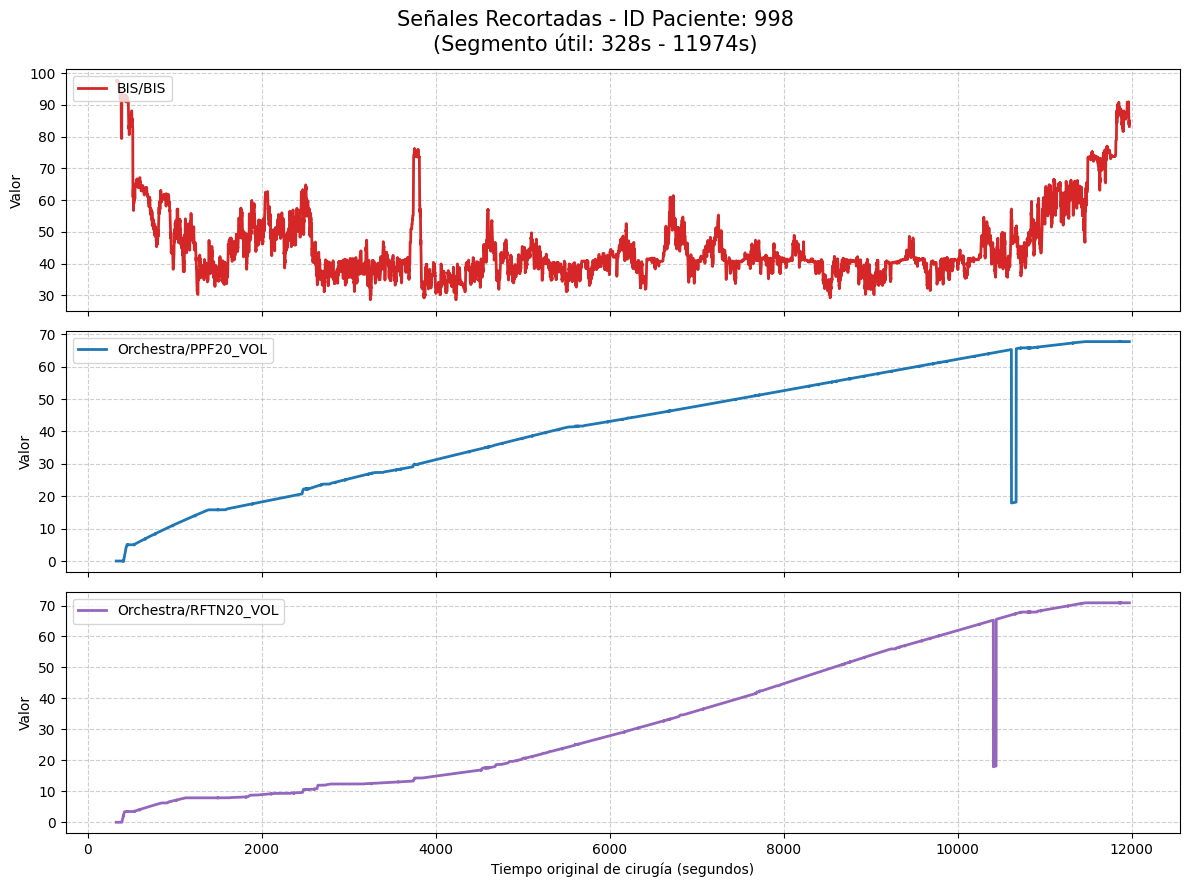

In [ ]:
import vitaldb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def procesar_y_graficar_paciente(ruta_archivo,pos):
    print("Iniciando lectura y análisis del primer paciente...\n" + "-"*50)
    
    # 1. Leer el primer ID del CSV
    try:
        df_ids = pd.read_csv(ruta_archivo)
        id_paciente = int(df_ids.iloc[pos, 0])
        print(f"ID seleccionado para el análisis: {id_paciente}")
    except Exception as error:
        print(f"Error al leer el CSV: {error}")
        return

    # Señales a descargar
    pistas = [
        'BIS/BIS',
        'Orchestra/PPF20_VOL',
        'Orchestra/RFTN20_VOL'
    ]

    # Descargar datos
    datos = vitaldb.load_case(id_paciente, pistas, interval=1)
    if datos is None or len(datos) == 0:
        print("El paciente no tiene datos disponibles en VitalDB.")
        return
        
    df = pd.DataFrame(datos, columns=pistas)
    df['Tiempo'] = np.arange(len(df))
    total_muestras = len(df)
    
    # 2 y 3. Revisar huecos en los extremos de las 3 señales
    limites = {}
    
    for pista in pistas:
        # Definir hueco (dato inválido)
        if pista == 'BIS/BIS':
            # Para BIS: NaN y 0 son huecos
            mascara_valida = ~(df[pista].isna() | (df[pista] == 0))
        else:
            # Para los VOL: Solo NaN son huecos (0 es válido)
            mascara_valida = ~df[pista].isna()
            
        indices_validos = np.where(mascara_valida)[0]
        
        if len(indices_validos) == 0:
            print(f"La señal {pista} está completamente vacía (puramente huecos).")
            return
            
        # Posiciones del primer y último dato bueno
        inicio_valido = indices_validos[0]
        fin_valido = indices_validos[-1]
        
        # Tamaño de los huecos
        tamano_hueco_inicial = inicio_valido 
        tamano_hueco_final = total_muestras - 1 - fin_valido
        
        limites[pista] = {
            'inicio': inicio_valido,
            'fin': fin_valido
        }
        
        print(f"Señal {pista}:")
        print(f"  -> Hueco inicial de {tamano_hueco_inicial} segundos (Dato real inicia en t={inicio_valido})")
        print(f"  -> Hueco final de {tamano_hueco_final} segundos (Dato real termina en t={fin_valido})")

    # Calcular el recorte máximo para sincronía
    # El hueco inicial más grande marca el punto de inicio de la porción útil
    inicio_sincronizado = max([limites[p]['inicio'] for p in pistas])
    
    # El hueco final más grande marca el punto de fin de la porción útil
    fin_sincronizado = min([limites[p]['fin'] for p in pistas])
    
    print("-" * 50)
    print(f"Zona de Recorte Sincronizado:")
    print(f"  -> Recorte de inicio dictado por t = {inicio_sincronizado}")
    print(f"  -> Recorte de fin dictado por t = {fin_sincronizado}")
    
    # 4. Recortar las señales por igual
    df_recortado = df.iloc[inicio_sincronizado : fin_sincronizado + 1]
    
    # 5. Graficar el resultado
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    colores = ['tab:red', 'tab:blue', 'tab:purple']
    
    for ax, pista, color in zip(axes, pistas, colores):
        # Graficar usando el Tiempo original para que los ejes X muestren el tiempo real transcurrido
        ax.plot(df_recortado['Tiempo'], df_recortado[pista], color=color, linewidth=2, label=f'{pista}')
        
        ax.set_ylabel('Valor')
        ax.legend(loc='upper left')
        ax.grid(True, linestyle='--', alpha=0.6)

    axes[-1].set_xlabel('Tiempo original de cirugía (segundos)')
    plt.suptitle(f'Señales Recortadas - ID Paciente: {id_paciente}\n(Segmento útil: {inicio_sincronizado}s - {fin_sincronizado}s)', fontsize=15)
    
    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
RUTA_CSV = r"C:\Users\yordi\Desktop\pacientes_ids.csv"

procesar_y_graficar_paciente(RUTA_CSV,131)

## Guardado de datos

In [ ]:
import vitaldb
import pandas as pd
import numpy as np
from pathlib import Path

def procesar_y_guardar_datos_crudos(ruta_archivo_ids):
    print("Iniciando extracción del primer paciente...\n" + "-"*50)
    
    # 1. Leer el primer ID del CSV
    try:
        df_ids = pd.read_csv(ruta_archivo_ids)
        id_paciente = int(df_ids.iloc[0, 0])
        print(f"ID seleccionado: {id_paciente}")
    except Exception as error:
        print(f"Error al leer el archivo de IDs: {error}")
        return

    # 2. Obtener datos demográficos de VitalDB
    try:
        print("Descargando metadatos clínicos...")
        df_casos = pd.read_csv("https://api.vitaldb.net/cases")
        info_paciente = df_casos[df_casos['caseid'] == id_paciente].iloc[0]
        
        edad = info_paciente['age']
        peso = info_paciente['weight']
        altura = info_paciente['height']
        sexo = info_paciente['sex'] # Es 'M' o 'F'
        
    except Exception as error:
        print(f"Error al obtener datos demográficos: {error}")
        return

    # 3. Descargar señales
    pistas = [
        'BIS/BIS',
        'Orchestra/PPF20_VOL',
        'Orchestra/RFTN20_VOL'
    ]
    datos = vitaldb.load_case(id_paciente, pistas, interval=1)
    
    if datos is None or len(datos) == 0:
        print("El paciente no tiene datos en las pistas solicitadas.")
        return
        
    df = pd.DataFrame(datos, columns=pistas)
    
    # 4. Encontrar los límites para el recorte sincronizado
    limites = {}
    for pista in pistas:
        if pista == 'BIS/BIS':
            mascara_valida = ~(df[pista].isna() | (df[pista] == 0))
        else:
            mascara_valida = ~df[pista].isna()
            
        indices_validos = np.where(mascara_valida)[0]
        if len(indices_validos) == 0:
            print(f"La señal {pista} está completamente vacía.")
            return
            
        limites[pista] = {
            'inicio': indices_validos[0],
            'fin': indices_validos[-1]
        }
        
    inicio_sincronizado = max([limites[p]['inicio'] for p in pistas])
    fin_sincronizado = min([limites[p]['fin'] for p in pistas])
    
    df_recortado = df.iloc[inicio_sincronizado : fin_sincronizado + 1].reset_index(drop=True)
    
    # 5. Estructurar el DataFrame final
    
    df_final = pd.DataFrame({
        't': np.arange(len(df_recortado)),
        'PPF20_VOL': df_recortado['Orchestra/PPF20_VOL'],
        'RFTN20_VOL': df_recortado['Orchestra/RFTN20_VOL'],
        'BIS': df_recortado['BIS/BIS'],
    })
    
    # Para evitar el LossySetitemError
    df_final['Edad'] = pd.Series(np.nan, dtype='float64')
    df_final['Peso'] = pd.Series(np.nan, dtype='float64')
    df_final['Altura'] = pd.Series(np.nan, dtype='float64')
    df_final['Sexo'] = pd.Series(None, dtype='object') 
    
    # Colocar los datos del paciente 
    df_final.loc[0, 'Edad'] = float(edad)
    df_final.loc[0, 'Peso'] = float(peso)
    df_final.loc[0, 'Altura'] = float(altura)
    df_final.loc[0, 'Sexo'] = str(sexo)
    
    # 6. Crear la carpeta "Datos crudos" en el escritorio y guardar el CSV
    carpeta_crudos = Path.home() / 'Desktop' / 'Datos crudos'
    carpeta_crudos.mkdir(parents=True, exist_ok=True)
    
    nombre_archivo = f"{id_paciente}_paciente.csv"
    ruta_salida = carpeta_crudos / nombre_archivo
    
    df_final.to_csv(ruta_salida, index=False)
    
    print("-" * 50)
    print(f"Proceso exitoso para el ID: {id_paciente}")
    print(f"Duración de la señal limpia: {len(df_recortado)} segundos.")
    print(f"Archivo crudo guardado en: {ruta_salida}")

# --- EJECUCIÓN ---
RUTA_CSV = r"C:\Users\yordi\Desktop\pacientes_ids.csv"

procesar_y_guardar_datos_crudos(RUTA_CSV)

Iniciando extracción del primer paciente...
--------------------------------------------------
ID seleccionado: 3
Descargando metadatos clínicos...
--------------------------------------------------
Proceso exitoso para el ID: 3
Duración de la señal limpia: 3711 segundos.
Archivo crudo guardado en: C:\Users\yordi\Desktop\Datos crudos\3_paciente.csv


In [ ]:
import vitaldb
import pandas as pd
import numpy as np
from pathlib import Path

def procesar_y_guardar_todos_datos_crudos(ruta_archivo_ids):
    print("Iniciando extracción masiva de pacientes...\n" + "-"*50)
    
    # 1. Leer la lista completa de IDs
    try:
        df_ids = pd.read_csv(ruta_archivo_ids)
        ids_pacientes = df_ids.iloc[:, 0].dropna().astype(int).tolist()
        total_pacientes = len(ids_pacientes)
        print(f"Se procesarán {total_pacientes} pacientes.")
    except Exception as error:
        print(f"Error al leer el archivo de IDs: {error}")
        return

    # 2. Descargar los metadatos globales 
    try:
        print("Descargando metadatos clínicos globales de VitalDB...")
        df_casos = pd.read_csv("https://api.vitaldb.net/cases")
    except Exception as error:
        print(f"Error al obtener datos demográficos globales: {error}")
        return

    pistas = [
        'BIS/BIS',
        'Orchestra/PPF20_VOL',
        'Orchestra/RFTN20_VOL'
    ]
    
    # Crear el directorio de salida
    carpeta_crudos = Path.home() / 'Desktop' / 'Datos crudos'
    carpeta_crudos.mkdir(parents=True, exist_ok=True)

    # 3. Iterar sobre todos los pacientes
    for indice, id_paciente in enumerate(ids_pacientes, start=1):
        progreso = f"[{indice}/{total_pacientes}]"
        
        try:
            # Obtener demografía específica
            info_paciente_df = df_casos[df_casos['caseid'] == id_paciente]
            if info_paciente_df.empty:
                print(f"{progreso} ID {id_paciente}: No se encontraron metadatos clínicos.")
                continue
                
            info_paciente = info_paciente_df.iloc[0]
            edad = float(info_paciente['age'])
            peso = float(info_paciente['weight'])
            altura = float(info_paciente['height'])
            sexo = str(info_paciente['sex'])
            
            # Descargar señales
            datos = vitaldb.load_case(id_paciente, pistas, interval=1)
            
            if datos is None or len(datos) == 0:
                print(f"{progreso} ID {id_paciente}: Sin datos disponibles.")
                continue
                
            df = pd.DataFrame(datos, columns=pistas)
            
            # Calcular límites de recorte
            limites = {}
            es_valido = True
            for pista in pistas:
                if pista == 'BIS/BIS':
                    mascara_valida = ~(df[pista].isna() | (df[pista] == 0))
                else:
                    mascara_valida = ~df[pista].isna()
                    
                indices_validos = np.where(mascara_valida)[0]
                if len(indices_validos) == 0:
                    print(f"{progreso} ID {id_paciente}: Señal {pista} completamente vacía.")
                    es_valido = False
                    break
                    
                limites[pista] = {
                    'inicio': indices_validos[0],
                    'fin': indices_validos[-1]
                }
                
            if not es_valido:
                continue
                
            inicio_sincronizado = max([limites[p]['inicio'] for p in pistas])
            fin_sincronizado = min([limites[p]['fin'] for p in pistas])
            
            if inicio_sincronizado >= fin_sincronizado:
                print(f"{progreso} ID {id_paciente}: No hay intersección temporal válida entre las señales.")
                continue
            
            # Recortar
            df_recortado = df.iloc[inicio_sincronizado : fin_sincronizado + 1].reset_index(drop=True)
            
            # Estructurar DataFrame
            df_final = pd.DataFrame({
                't': np.arange(len(df_recortado)),
                'PPF20_VOL': df_recortado['Orchestra/PPF20_VOL'],
                'RFTN20_VOL': df_recortado['Orchestra/RFTN20_VOL'],
                'BIS': df_recortado['BIS/BIS'],
            })
            
            # Prevenir errores de tipos de datos 
            df_final['Edad'] = pd.Series(np.nan, dtype='float64')
            df_final['Peso'] = pd.Series(np.nan, dtype='float64')
            df_final['Altura'] = pd.Series(np.nan, dtype='float64')
            df_final['Sexo'] = pd.Series(None, dtype='object')
            
            # Asignar metadatos 
            df_final.loc[0, 'Edad'] = edad
            df_final.loc[0, 'Peso'] = peso
            df_final.loc[0, 'Altura'] = altura
            df_final.loc[0, 'Sexo'] = sexo
            
            # Guardar archivo
            nombre_archivo = f"Paciente_{id_paciente}.csv"
            ruta_salida = carpeta_crudos / nombre_archivo
            
            df_final.to_csv(ruta_salida, index=False)
            print(f"{progreso} Procesado y guardado exitosamente: {nombre_archivo}")
            
        except Exception as error:
            print(f"{progreso} Error procesando ID {id_paciente}: {error}")

    print("-" * 50)
    print("PROCESO MASIVO COMPLETADO")

# --- EJECUCIÓN ---
RUTA_CSV = r"C:\Users\yordi\Desktop\pacientes_ids.csv"

procesar_y_guardar_todos_datos_crudos(RUTA_CSV)

Iniciando extracción masiva de pacientes...
--------------------------------------------------
Se procesarán 860 pacientes.
Descargando metadatos clínicos globales de VitalDB...
[1/860] Procesado y guardado exitosamente: Paciente_3.csv
[2/860] Procesado y guardado exitosamente: Paciente_9.csv
[3/860] Procesado y guardado exitosamente: Paciente_16.csv
[4/860] Procesado y guardado exitosamente: Paciente_17.csv
[5/860] Procesado y guardado exitosamente: Paciente_36.csv
[6/860] Procesado y guardado exitosamente: Paciente_40.csv
[7/860] Procesado y guardado exitosamente: Paciente_57.csv
[8/860] Procesado y guardado exitosamente: Paciente_60.csv
[9/860] Procesado y guardado exitosamente: Paciente_72.csv
[10/860] Procesado y guardado exitosamente: Paciente_78.csv
[11/860] Procesado y guardado exitosamente: Paciente_104.csv
[12/860] Procesado y guardado exitosamente: Paciente_121.csv
[13/860] Procesado y guardado exitosamente: Paciente_134.csv
[14/860] Procesado y guardado exitosamente: Pacien